# 1. Inicialización del Entorno y Librerías
Verificación de las versiones de `TensorFlow` y `Keras` instaladas en el entorno de ejecución. Configuración de filtros para omitir advertencias (*warnings*) y asegurar la reproducibilidad del script.

In [ ]:
import tensorflow as tf
print(f'tensorflow version: {tf.__version__}')
print(f'tensorflow keras version: {tf.keras.__version__}')

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Detect hardware, return appropriate distribution strategy
try:
    TPU = tf.distribute.cluster_resolver.TPUClusterResolver()  # TPU detection. No parameters necessary if TPU_NAME environment variable is set. On Kaggle this is always the case.
    print('Running on TPU ', TPU.master())
except ValueError:
    print('Running on GPU')
    TPU = None

if TPU:
    tf.config.experimental_connect_to_cluster(TPU)
    tf.tpu.experimental.initialize_tpu_system(TPU)
    strategy = tf.distribute.experimental.TPUStrategy(TPU)
else:
    strategy = tf.distribute.get_strategy() # default distribution strategy in Tensorflow. Works on CPU and single GPU.

REPLICAS = strategy.num_replicas_in_sync
print(f'REPLICAS: {REPLICAS}')




Running on GPU
REPLICAS: 1


In [3]:
!python -m pip install --upgrade pip -q
!pip install keras-cv -q

In [4]:
!pip install albumentations -q

In [5]:
#import keras_applications
#from vit_keras import vit, utils
import keras_cv
from tensorflow import keras
import tensorflow as tf

import os, glob
import random
from sklearn.model_selection import train_test_split
import cv2
import numpy as np
import pandas as pd
import multiprocessing
from copy import deepcopy
from sklearn.metrics import precision_recall_curve, auc
import tensorflow.keras as keras
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.utils import Sequence
from albumentations import Compose, VerticalFlip, HorizontalFlip, Rotate, GridDistortion,CenterCrop
import matplotlib.pyplot as plt
from IPython.display import Image
from tqdm import tqdm_notebook as tqdm
from numpy.random import seed
seed(10)
tf.random.set_seed(10)
%matplotlib inline

# 2. Diseño de Métricas de Control y Políticas Dinámicas
Desarrollo de la métrica personalizada `DiceCoefficient` para evaluar el solapamiento implícito en conjuntos vacíos y del callback `PrAucCallback` para monitorizar el área bajo la curva Precisión-Recall (PR AUC) media por época. Se configuran políticas automatizadas de parada temprana (*Early Stopping*) y reducción dinámica de la tasa de aprendizaje en meseta.

In [22]:
class DiceCoefficient(tf.keras.metrics.Metric):
    def __init__(self, name='dice_coefficient', **kwargs):
        super().__init__(name=name, **kwargs)
        self.dice_sum = self.add_weight(name='dice_sum', initializer='zeros')
        self.count   = self.add_weight(name='count',    initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        intersection = tf.reduce_sum(y_true * y_pred, axis=1)
        union        = tf.reduce_sum(y_true, axis=1) + tf.reduce_sum(y_pred, axis=1)

        # Dice = 1 cuando ambos son vacíos (según la competencia)
        dice = tf.where(union == 0, 1.0, (2.0 * intersection) / union)
        self.dice_sum.assign_add(tf.reduce_sum(dice))
        self.count.assign_add(tf.cast(tf.shape(y_true)[0], tf.float32))

    def result(self):
        return self.dice_sum / self.count

    def reset_state(self):
        self.dice_sum.assign(0.0)
        self.count.assign(0.0)

In [6]:
test_imgs_folde = '/kaggle/input/competitions/understanding_cloud_organization/test_images'
train_imgs_folder  = '/kaggle/input/competitions/understanding_cloud_organization/train_images'
num_cores = multiprocessing.cpu_count()

# 3. Ingesta de Datos y Codificación Multi-Etiqueta
Carga del dataset analítico y filtrado de registros nulos en formato RLE (*Run-Length Encoding*). Agrupamiento de clases por imagen única y transformación a vectores binarios (*Multi-Hot Encoding*) para dar soporte a la clasificación multi-etiqueta de las estructuras nubosas (`Fish`, `Flower`, `Sugar`, `Gravel`).

In [8]:
train_df = pd.read_csv('/kaggle/input/competitions/understanding_cloud_organization/train.csv')
train_df.head()

,Image_Label,EncodedPixels
0,0011165.jpg_Fish,264918 937 266318 937 267718 937 269118 937 27...
1,0011165.jpg_Flower,1355565 1002 1356965 1002 1358365 1002 1359765...
2,0011165.jpg_Gravel,NaN
3,0011165.jpg_Sugar,NaN
4,002be4f.jpg_Fish,233813 878 235213 878 236613 878 238010 881 23...


In [9]:
train_df = train_df[~train_df['EncodedPixels'].isnull()]
train_df['Image'] = train_df['Image_Label'].map(lambda x: x.split('_')[0])
train_df['Class'] = train_df['Image_Label'].map(lambda x: x.split('_')[1])
classes = train_df['Class'].unique()
train_df = train_df.groupby('Image')['Class'].agg(set).reset_index()
for class_name in classes:
    train_df[class_name] = train_df['Class'].map(lambda x: 1 if class_name in x else 0)
train_df.head()

,Image,Class,Fish,Flower,Sugar,Gravel
0,0011165.jpg,"{Fish, Flower}",1,1,0,0
1,002be4f.jpg,"{Fish, Flower, Sugar}",1,1,1,0
2,0031ae9.jpg,"{Fish, Flower, Sugar}",1,1,1,0
3,0035239.jpg,"{Flower, Gravel}",0,1,0,1
4,003994e.jpg,"{Fish, Gravel, Sugar}",1,0,1,1


In [10]:
# dictionary for fast access to ohe vectors
img_2_ohe_vector = {img:vec for img, vec in zip(train_df['Image'], train_df.iloc[:, 2:].values)}

In [11]:
train_imgs, val_imgs = train_test_split(train_df['Image'].values, 
                                        test_size=0.1, 
                                        stratify=train_df['Class'].map(lambda x: str(sorted(list(x)))), # sorting present classes in lexicographical order, just to be sure
                                        random_state=43)

# 4. Pipeline de Datos y Aumentación Estocástica
Implementación de una clase personalizada `DataGenerator` (heredera de `tf.keras.utils.Sequence`) para la lectura asíncrona, redimensionamiento uniforme a $224 \times 224 \times 3$ y normalización de tensores en lotes (*batches* de 32). Se integra la librería `albumentations` para regularizar el modelo mediante transformaciones espaciales geométricas y giros estocásticos.

In [12]:
class DataGenenerator(Sequence):
    def __init__(self, images_list=None, folder_imgs=train_imgs_folder, 
                 batch_size=32, shuffle=True, augmentation=None,
                 resized_height=224, resized_width=224, num_channels=3):
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augmentation = augmentation
        if images_list is None:
            self.images_list = os.listdir(folder_imgs)
        else:
            self.images_list = deepcopy(images_list)
        self.folder_imgs = folder_imgs
        self.len = len(self.images_list) // self.batch_size
        self.resized_height = resized_height
        self.resized_width = resized_width
        self.num_channels = num_channels
        self.num_classes = 4
        self.is_test = not 'train' in folder_imgs
        if not shuffle and not self.is_test:
            self.labels = [img_2_ohe_vector[img] for img in self.images_list[:self.len*self.batch_size]]

    def __len__(self):
        return self.len
    
    def on_epoch_start(self):
        if self.shuffle:
            random.shuffle(self.images_list)

    def __getitem__(self, idx):
        current_batch = self.images_list[idx * self.batch_size: (idx + 1) * self.batch_size]
        X = np.empty((self.batch_size, self.resized_height, self.resized_width, self.num_channels))
        y = np.empty((self.batch_size, self.num_classes))

        for i, image_name in enumerate(current_batch):
            path = os.path.join(self.folder_imgs, image_name)
            img = cv2.resize(cv2.imread(path), (self.resized_height, self.resized_width)).astype(np.float32)
            if not self.augmentation is None:
                augmented = self.augmentation(image=img)
                img = augmented['image']
            X[i, :, :, :] = img/255.0
            if not self.is_test:
                y[i, :] = img_2_ohe_vector[image_name]
        return X, y

    def get_labels(self):
        if self.shuffle:
            images_current = self.images_list[:self.len*self.batch_size]
            labels = [img_2_ohe_vector[img] for img in images_current]
        else:
            labels = self.labels
        return np.array(labels)

In [13]:
albumentations_train = Compose([
    VerticalFlip(), HorizontalFlip(), Rotate(limit=30), GridDistortion()
], p=1)

In [14]:
data_generator_train = DataGenenerator(train_imgs, augmentation=albumentations_train)
data_generator_train_eval = DataGenenerator(train_imgs, shuffle=False)
data_generator_val = DataGenenerator(val_imgs, shuffle=False)

In [15]:
class PrAucCallback(Callback):
    def __init__(self, data_generator, num_workers=num_cores, 
                 early_stopping_patience=5, 
                 plateau_patience=3, reduction_rate=0.5,
                 stage='train', checkpoints_path='checkpoints/'):
        super(Callback, self).__init__()
        self.data_generator = data_generator
        self.num_workers = num_workers
        self.class_names = ['Fish', 'Flower', 'Sugar', 'Gravel']
        self.history = [[] for _ in range(len(self.class_names) + 1)] # to store per each class and also mean PR AUC
        self.early_stopping_patience = early_stopping_patience
        self.plateau_patience = plateau_patience
        self.reduction_rate = reduction_rate
        self.stage = stage
        self.best_pr_auc = -float('inf')
        if not os.path.exists(checkpoints_path):
            os.makedirs(checkpoints_path)
        self.checkpoints_path = checkpoints_path
        
    def compute_pr_auc(self, y_true, y_pred):
        pr_auc_mean = 0
        print(f"\n{'#'*30}\n")
        for class_i in range(len(self.class_names)):
            precision, recall, _ = precision_recall_curve(y_true[:, class_i], y_pred[:, class_i])
            pr_auc = auc(recall, precision)
            pr_auc_mean += pr_auc/len(self.class_names)
            print(f"PR AUC {self.class_names[class_i]}, {self.stage}: {pr_auc:.3f}\n")
            self.history[class_i].append(pr_auc)        
        print(f"\n{'#'*20}\n PR AUC mean, {self.stage}: {pr_auc_mean:.3f}\n{'#'*20}\n")
        self.history[-1].append(pr_auc_mean)
        return pr_auc_mean
              
    def is_patience_lost(self, patience):
        if len(self.history[-1]) > patience:
            best_performance = max(self.history[-1][-(patience + 1):-1])
            return best_performance == self.history[-1][-(patience + 1)] and best_performance >= self.history[-1][-1]    
              
    def early_stopping_check(self, pr_auc_mean):
        if self.is_patience_lost(self.early_stopping_patience):
            self.model.stop_training = True    
              
    def model_checkpoint(self, pr_auc_mean, epoch):
        if pr_auc_mean > self.best_pr_auc:
            # remove previous checkpoints to save space
            for checkpoint in glob.glob(os.path.join(self.checkpoints_path, 'classifier_epoch_*')):
                os.remove(checkpoint)
        self.best_pr_auc = pr_auc_mean
        self.model.save(os.path.join(self.checkpoints_path, f'classifier_epoch_{epoch}_val_pr_auc_{pr_auc_mean}.h5'))              
        print(f"\n{'#'*20}\nSaved new checkpoint\n{'#'*20}\n")
              
    def reduce_lr_on_plateau(self):
        if self.is_patience_lost(self.plateau_patience):
            # new_lr = float(keras.backend.get_value(self.model.optimizer.lr)) * self.reduction_rate
            # keras.backend.set_value(self.model.optimizer.lr, new_lr)

            new_lr = float(self.model.optimizer.learning_rate.numpy()) * self.reduction_rate
            self.model.optimizer.learning_rate.assign(new_lr)

            print(f"\n{'#'*20}\nReduced learning rate to {new_lr}.\n{'#'*20}\n")
        
    def on_epoch_end(self, epoch, logs={}):
        # y_pred = self.model.predict_generator(self.data_generator, workers=self.num_workers)
        # y_pred = self.model.predict(self.data_generator, workers=self.num_workers)
        y_pred = self.model.predict(self.data_generator)
        y_true = self.data_generator.get_labels()
        # estimate AUC under precision recall curve for each class
        pr_auc_mean = self.compute_pr_auc(y_true, y_pred)
              
        if self.stage == 'val':
            # early stop after early_stopping_patience=4 epochs of no improvement in mean PR AUC
            self.early_stopping_check(pr_auc_mean)

            # save a model with the best PR AUC in validation
            self.model_checkpoint(pr_auc_mean, epoch)

            # reduce learning rate on PR AUC plateau
            self.reduce_lr_on_plateau()            
        
    def get_pr_auc_history(self):
        return self.history

In [16]:
train_metric_callback = PrAucCallback(data_generator_train_eval)
val_callback = PrAucCallback(data_generator_val, stage='val')


In [17]:
from tensorflow.keras import layers, Model

def transformer_block(x, heads, dim, mlp_dim):
    # Atención multi-cabeza con residual
    y = layers.LayerNormalization()(x)
    y = layers.MultiHeadAttention(num_heads=heads, key_dim=dim // heads)(y, y)
    x = layers.Add()([x, y])
    # MLP con residual
    y = layers.LayerNormalization()(x)
    y = layers.Dense(mlp_dim, activation='gelu')(y)
    y = layers.Dense(dim)(y)
    x = layers.Add()([x, y])
    return x

def get_model(image_size=224, patch_size=16, num_classes=4,
              dim=768, depth=12, heads=12, mlp_dim=3072):

    num_patches = (image_size // patch_size) ** 2  # 196 patches

    inputs = layers.Input(shape=(image_size, image_size, 3))

    # Divide imagen en patches y proyecta a dimensión dim
    x = layers.Conv2D(dim, kernel_size=patch_size, strides=patch_size)(inputs)
    x = layers.Reshape((num_patches, dim))(x)

    # Embedding posicional
    positions = tf.range(num_patches)
    x = x + layers.Embedding(num_patches, dim)(positions)

    # Bloques Transformer (ViT-B16: 12 bloques)
    for _ in range(depth):
        x = transformer_block(x, heads, dim, mlp_dim)

    x = layers.LayerNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)          # (batch, 768)
    y_pred = layers.Dense(num_classes, activation='sigmoid')(x)  # (batch, 4)

    return Model(inputs=inputs, outputs=y_pred)

model = get_model()

I0000 00:00:1780675031.897452     320 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780675031.902591     320 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# 5. Fase 0: Extracción de Características (Feature Extraction)
Congelamiento de los parámetros de la arquitectura base del Vision Transformer (`trainable = False`) para aislar y entrenar exclusivamente los pesos del cabezal lineal de salida (`Dense`) mediante el optimizador Adam ($\alpha=0.01$) y la pérdida de entropía cruzada binaria durante 10 épocas.

In [18]:
for base_layer in model.layers[:-1]:
    base_layer.trainable = False

model.compile(optimizer=Adam(learning_rate=0.01),
              loss='binary_crossentropy',
              metrics=[keras.metrics.BinaryAccuracy(),
                       DiceCoefficient()])
history_0 = model.fit(data_generator_train,
                      validation_data=data_generator_val,
                      epochs=10,
                      callbacks=[train_metric_callback, val_callback],
                      verbose=1) 

Epoch 1/10


I0000 00:00:1780675059.009782     403 service.cc:152] XLA service 0x7b2aa80038d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780675059.009813     403 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780675059.009830     403 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780675061.016076     403 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780675064.580640     403 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


155/155 ━━━━━━━━━━━━━━━━━━━━ 114s 713ms/step

##############################

PR AUC Fish, train: 0.571

PR AUC Flower, train: 0.575

PR AUC Sugar, train: 0.768

PR AUC Gravel, train: 0.643


####################
 PR AUC mean, train: 0.639
####################

17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 643ms/step



##############################

PR AUC Fish, val: 0.509

PR AUC Flower, val: 0.633

PR AUC Sugar, val: 0.784

PR AUC Gravel, val: 0.625


####################
 PR AUC mean, val: 0.638
####################


####################
Saved new checkpoint
####################

155/155 ━━━━━━━━━━━━━━━━━━━━ 288s 2s/step - binary_accuracy: 0.5540 - loss: 0.7347 - val_binary_accuracy: 0.5910 - val_loss: 0.6749
Epoch 2/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 93s 597ms/step

##############################

PR AUC Fish, train: 0.582

PR AUC Flower, train: 0.577

PR AUC Sugar, train: 0.797

PR AUC Gravel, train: 0.645


####################
 PR AUC mean, train: 0.650
####################

17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 602ms/step



##############################

PR AUC Fish, val: 0.519

PR AUC Flower, val: 0.635

PR AUC Sugar, val: 0.791

PR AUC Gravel, val: 0.632


####################
 PR AUC mean, val: 0.644
####################


####################
Saved new checkpoint
####################

155/155 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step - binary_accuracy: 0.5617 - loss: 0.7188 - val_binary_accuracy: 0.5786 - val_loss: 0.6711
Epoch 3/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 94s 603ms/step

##############################

PR AUC Fish, train: 0.591

PR AUC Flower, train: 0.607

PR AUC Sugar, train: 0.803

PR AUC Gravel, train: 0.648


####################
 PR AUC mean, train: 0.662
####################

17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 621ms/step


...


##############################

PR AUC Fish, val: 0.531

PR AUC Flower, val: 0.672

PR AUC Sugar, val: 0.797

PR AUC Gravel, val: 0.631


####################
 PR AUC mean, val: 0.658
####################


####################
Saved new checkpoint
####################

155/155 ━━━━━━━━━━━━━━━━━━━━ 232s 1s/step - binary_accuracy: 0.5800 - loss: 0.7032 - val_binary_accuracy: 0.5919 - val_loss: 0.6787
Epoch 7/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 93s 596ms/step

##############################

PR AUC Fish, train: 0.586

PR AUC Flower, train: 0.637

PR AUC Sugar, train: 0.812

PR AUC Gravel, train: 0.648


####################
 PR AUC mean, train: 0.671
####################

17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 610ms/step



##############################

PR AUC Fish, val: 0.546

PR AUC Flower, val: 0.679

PR AUC Sugar, val: 0.792

PR AUC Gravel, val: 0.639


####################
 PR AUC mean, val: 0.664
####################


####################
Saved new checkpoint
####################

155/155 ━━━━━━━━━━━━━━━━━━━━ 236s 2s/step - binary_accuracy: 0.5901 - loss: 0.6835 - val_binary_accuracy: 0.5588 - val_loss: 0.7312
Epoch 8/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 95s 613ms/step

##############################

PR AUC Fish, train: 0.610

PR AUC Flower, train: 0.641

PR AUC Sugar, train: 0.813

PR AUC Gravel, train: 0.651


####################
 PR AUC mean, train: 0.679
####################

17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 595ms/step



##############################

PR AUC Fish, val: 0.546

PR AUC Flower, val: 0.678

PR AUC Sugar, val: 0.791

PR AUC Gravel, val: 0.639


####################
 PR AUC mean, val: 0.663
####################


####################
Saved new checkpoint
####################

155/155 ━━━━━━━━━━━━━━━━━━━━ 239s 2s/step - binary_accuracy: 0.5976 - loss: 0.6831 - val_binary_accuracy: 0.6140 - val_loss: 0.6580
Epoch 9/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 95s 608ms/step

##############################

PR AUC Fish, train: 0.613

PR AUC Flower, train: 0.644

PR AUC Sugar, train: 0.814

PR AUC Gravel, train: 0.654


####################
 PR AUC mean, train: 0.681
####################

17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 624ms/step



##############################

PR AUC Fish, val: 0.539

PR AUC Flower, val: 0.684

PR AUC Sugar, val: 0.789

PR AUC Gravel, val: 0.632


####################
 PR AUC mean, val: 0.661
####################


####################
Saved new checkpoint
####################

155/155 ━━━━━━━━━━━━━━━━━━━━ 241s 2s/step - binary_accuracy: 0.5943 - loss: 0.6897 - val_binary_accuracy: 0.5846 - val_loss: 0.6866
Epoch 10/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 95s 612ms/step

##############################

PR AUC Fish, train: 0.615

PR AUC Flower, train: 0.639

PR AUC Sugar, train: 0.814

PR AUC Gravel, train: 0.651


####################
 PR AUC mean, train: 0.680
####################

17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 617ms/step



##############################

PR AUC Fish, val: 0.544

PR AUC Flower, val: 0.673

PR AUC Sugar, val: 0.788

PR AUC Gravel, val: 0.627


####################
 PR AUC mean, val: 0.658
####################


####################
Saved new checkpoint
####################


####################
Reduced learning rate to 0.004999999888241291.
####################

155/155 ━━━━━━━━━━━━━━━━━━━━ 241s 2s/step - binary_accuracy: 0.5846 - loss: 0.7256 - val_binary_accuracy: 0.6062 - val_loss: 0.7395


# 6. Fase 1: Ajuste Fino Completo (Fine-Tuning)
Liberación de todos los parámetros internos de los 12 bloques de encoder del Vision Transformer (`trainable = True`) para optimizar de manera conjunta toda la red. Se busca reajustar las matrices de atención a las texturas específicas del dataset atmosférico durante 15 épocas adicionales.

In [23]:
for base_layer in model.layers[:-1]:
    base_layer.trainable = True
    
model.compile(optimizer=Adam(learning_rate=0.01),
              loss='binary_crossentropy',
              metrics=[keras.metrics.BinaryAccuracy(),
                       DiceCoefficient()])
history_1 = model.fit(data_generator_train,
                      validation_data=data_generator_val,
                      epochs=15,
                      callbacks=[train_metric_callback, val_callback],
                      verbose=1)

Epoch 1/15
155/155 ━━━━━━━━━━━━━━━━━━━━ 99s 614ms/step

##############################

PR AUC Fish, train: 0.505

PR AUC Flower, train: 0.439

PR AUC Sugar, train: 0.689

PR AUC Gravel, train: 0.517


####################
 PR AUC mean, train: 0.538
####################

17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 594ms/step



##############################

PR AUC Fish, val: 0.482

PR AUC Flower, val: 0.435

PR AUC Sugar, val: 0.664

PR AUC Gravel, val: 0.491


####################
 PR AUC mean, val: 0.518
####################


####################
Saved new checkpoint
####################


####################
Reduced learning rate to 0.004999999888241291.
####################

155/155 ━━━━━━━━━━━━━━━━━━━━ 373s 2s/step - binary_accuracy: 0.5279 - dice_coefficient: 0.5197 - loss: 1.3987 - val_binary_accuracy: 0.4825 - val_dice_coefficient: 0.5141 - val_loss: 0.7215
Epoch 2/15
155/155 ━━━━━━━━━━━━━━━━━━━━ 96s 615ms/step

##############################

PR AUC Fish, train: 0.511

PR AUC Flower, train: 0.448

PR AUC Sugar, train: 0.696

PR AUC Gravel, train: 0.518


####################
 PR AUC mean, train: 0.543
####################

17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 601ms/step

##############################

PR AUC Fish, val: 0.493

PR AUC Flower, val: 0.449

PR AUC Sugar, val: 0.667

PR AUC Gravel, val: 0.


####################
Saved new checkpoint
####################


####################
Reduced learning rate to 0.0024999999441206455.
####################

155/155 ━━━━━━━━━━━━━━━━━━━━ 326s 2s/step - binary_accuracy: 0.5395 - dice_coefficient: 0.5253 - loss: 0.7120 - val_binary_accuracy: 0.5699 - val_dice_coefficient: 0.5535 - val_loss: 0.6911


In [24]:
history_0

In [25]:
history_1

In [26]:
def plot_with_dots(ax, np_array):
    ax.scatter(list(range(1, len(np_array) + 1)), np_array, s=50)
    ax.plot(list(range(1, len(np_array) + 1)), np_array)

# 7. Evaluación de Resultados y Diagnóstico de Convergencia
Visualización gráfica de las curvas de función de pérdida (*Loss*) y evolución del PR AUC medio tanto en el set de entrenamiento como en el de validación. Esta sección permite diagnosticar la estabilidad de la transición entre fases y la presencia de sobreajuste u olvido catastrófico.

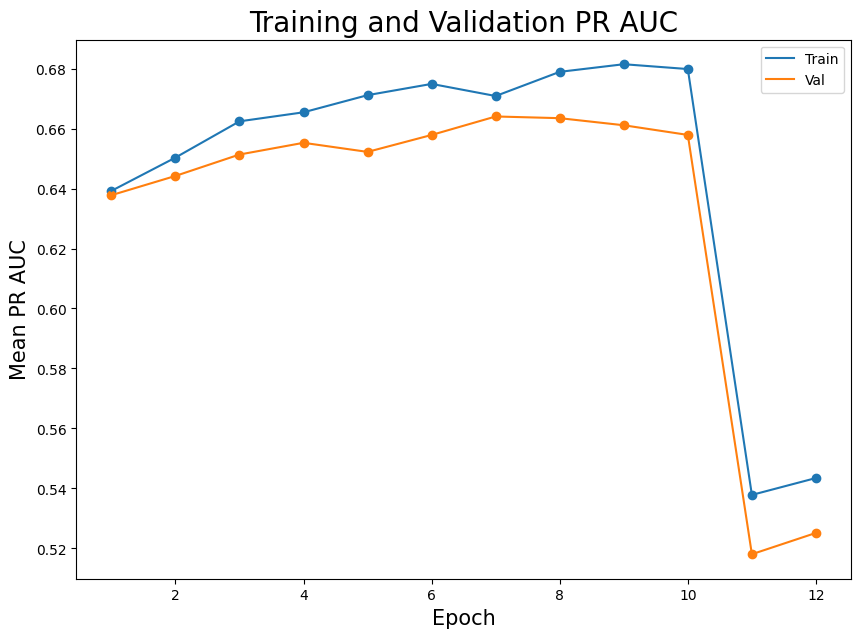

In [27]:
pr_auc_history_train = train_metric_callback.get_pr_auc_history()
pr_auc_history_val = val_callback.get_pr_auc_history()

plt.figure(figsize=(10, 7))
plt.plot(list(range(1, len(pr_auc_history_train[-1]) + 1)), pr_auc_history_train[-1])
plt.plot(list(range(1, len(pr_auc_history_val[-1]) + 1)), pr_auc_history_val[-1])
plt.scatter(list(range(1, len(pr_auc_history_train[-1]) + 1)), pr_auc_history_train[-1])
plt.scatter(list(range(1, len(pr_auc_history_val[-1]) + 1)), pr_auc_history_val[-1])
plt.xlabel('Epoch', fontsize=15)
plt.ylabel('Mean PR AUC', fontsize=15)
plt.legend(['Train', 'Val'])
plt.title('Training and Validation PR AUC', fontsize=20)
plt.savefig('pr_auc_hist.png')

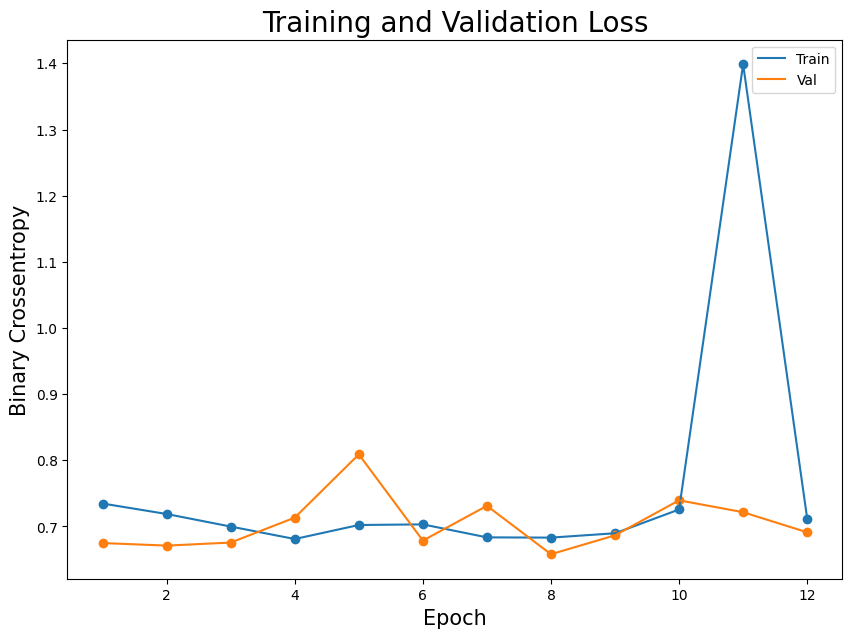

In [28]:
plt.figure(figsize=(10, 7))
# plot_with_dots(plt, history_0.history['loss']+history_1.history['loss'])
# plot_with_dots(plt, history_0.history['val_loss']+history_1.history['val_loss'])
plt.plot(list(range(1, len(history_0.history['loss']+history_1.history['loss']) + 1)), history_0.history['loss']+history_1.history['loss'])
plt.plot(list(range(1, len(history_0.history['val_loss']+history_1.history['val_loss']) + 1)), history_0.history['val_loss']+history_1.history['val_loss'])
plt.scatter(list(range(1, len(history_0.history['loss']+history_1.history['loss']) + 1)), history_0.history['loss']+history_1.history['loss'])
plt.scatter(list(range(1, len(history_0.history['val_loss']+history_1.history['val_loss']) + 1)), history_0.history['val_loss']+history_1.history['val_loss'])
plt.xlabel('Epoch', fontsize=15)
plt.ylabel('Binary Crossentropy', fontsize=15)
plt.legend(['Train', 'Val'])
plt.title('Training and Validation Loss', fontsize=20)
plt.savefig('loss_hist.png')

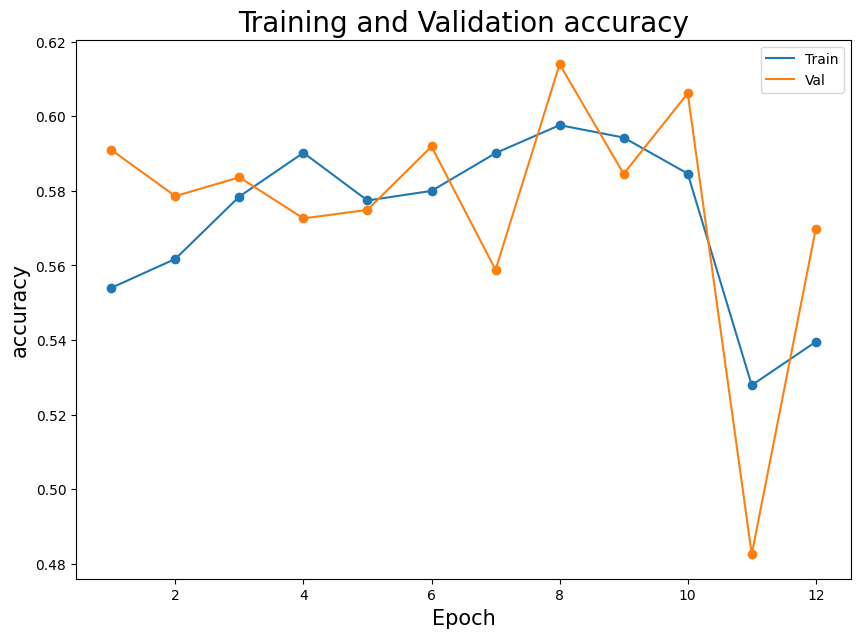

In [29]:
plt.figure(figsize=(10, 7))
# plot_with_dots(plt, history_0.history['loss']+history_1.history['loss'])
# plot_with_dots(plt, history_0.history['val_loss']+history_1.history['val_loss'])
plt.plot(list(range(1, len(history_0.history['binary_accuracy']+history_1.history['binary_accuracy']) + 1)), history_0.history['binary_accuracy']+history_1.history['binary_accuracy'])
plt.plot(list(range(1, len(history_0.history['val_binary_accuracy']+history_1.history['val_binary_accuracy']) + 1)), history_0.history['val_binary_accuracy']+history_1.history['val_binary_accuracy'])
plt.scatter(list(range(1, len(history_0.history['binary_accuracy']+history_1.history['binary_accuracy']) + 1)), history_0.history['binary_accuracy']+history_1.history['binary_accuracy'])
plt.scatter(list(range(1, len(history_0.history['val_binary_accuracy']+history_1.history['val_binary_accuracy']) + 1)), history_0.history['val_binary_accuracy']+history_1.history['val_binary_accuracy'])
plt.xlabel('Epoch', fontsize=15)
plt.ylabel('accuracy', fontsize=15)
plt.legend(['Train', 'Val'])
plt.title('Training and Validation accuracy', fontsize=20)
plt.savefig('accuracy_hist.png')

17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 612ms/step


0it [00:00, ?it/s]

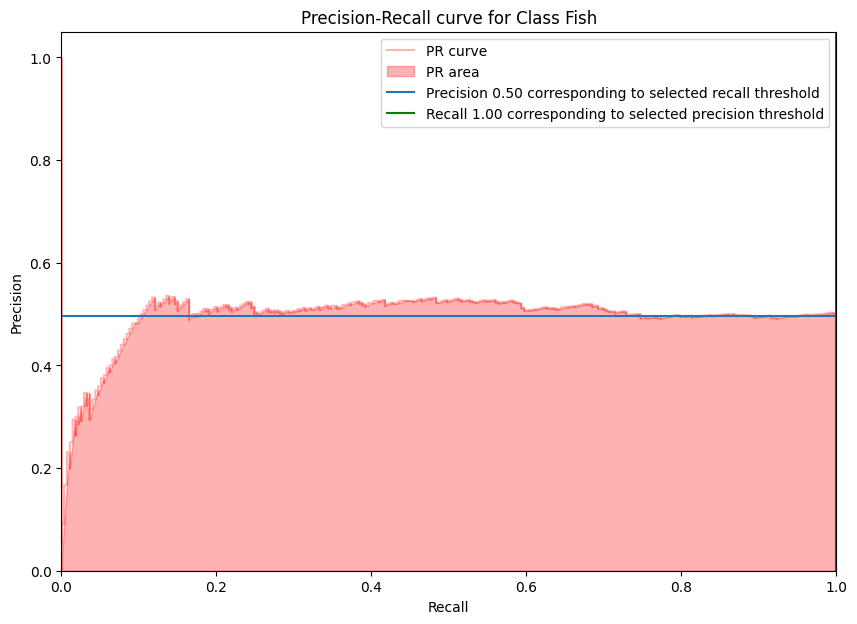

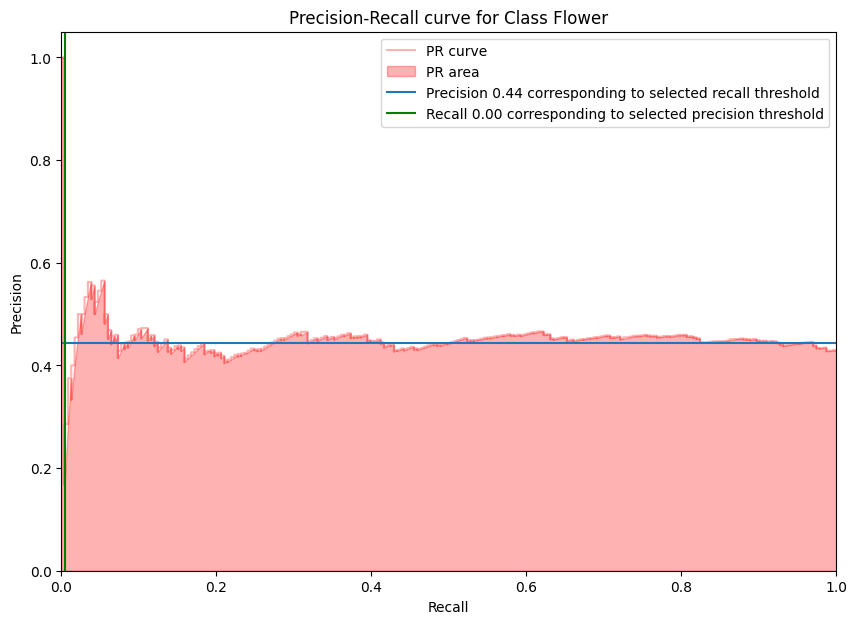

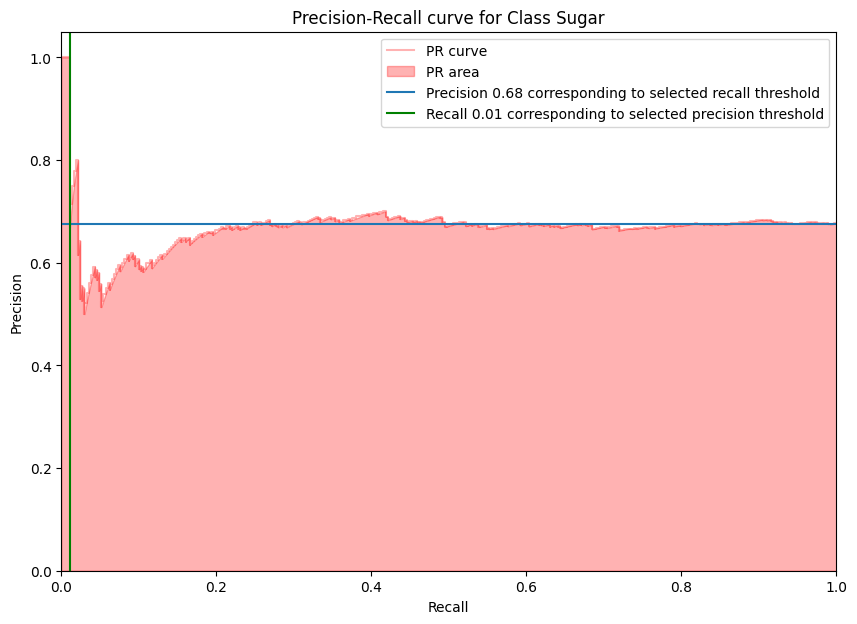

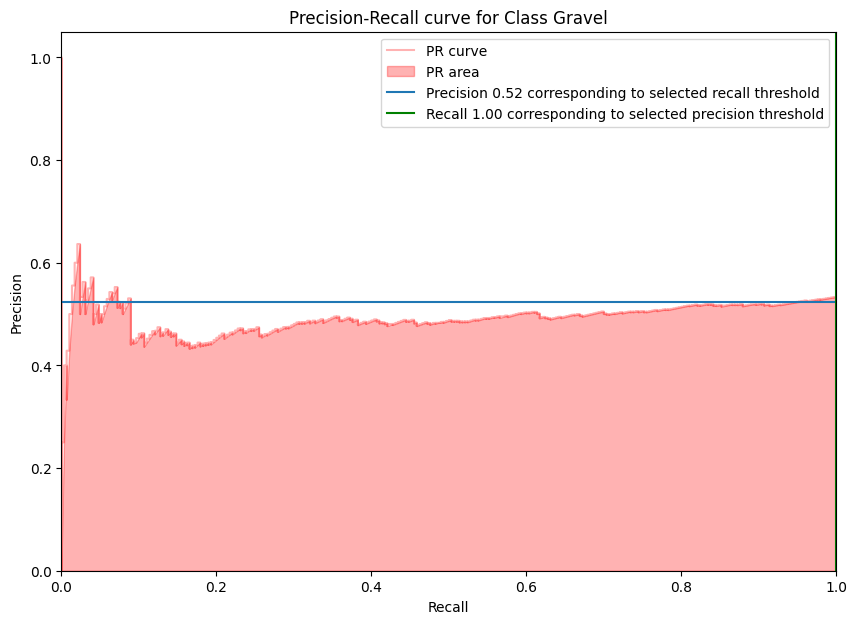

In [36]:
class_names = ['Fish', 'Flower', 'Sugar', 'Gravel']

def get_threshold_for_recall(y_true, y_pred, class_i, recall_threshold=0.95, precision_threshold=0.94, plot=False):
    precision, recall, thresholds = precision_recall_curve(y_true[:, class_i], y_pred[:, class_i])
    i = len(thresholds) - 1
    best_recall_threshold = None
    while best_recall_threshold is None:
        next_threshold = thresholds[i]
        next_recall = recall[i]
        if next_recall >= recall_threshold:
            best_recall_threshold = next_threshold
        i -= 1
        
    # --- MODIFICACIÓN AQUÍ: Evita el IndexError si la lista queda vacía ---
    filtered_thresholds = [thres for prec, thres in zip(precision, thresholds) if prec >= precision_threshold]
    best_precision_threshold = filtered_thresholds[0] if filtered_thresholds else thresholds[0]
    
    if plot:
        plt.figure(figsize=(10, 7))
        plt.step(recall, precision, color='r', alpha=0.3, where='post')
        plt.fill_between(recall, precision, alpha=0.3, color='r')
        plt.axhline(y=precision[i + 1])
        
        # --- MODIFICACIÓN AQUÍ TAMBIÉN: Protege el gráfico de quedarse sin datos ---
        filtered_recalls = [rec for rec, thres in zip(recall, thresholds) if thres == best_precision_threshold]
        recall_for_prec_thres = filtered_recalls[0] if filtered_recalls else 0.0
        
        plt.axvline(x=recall_for_prec_thres, color='g')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.ylim([0.0, 1.05])
        plt.xlim([0.0, 1.0])
        plt.legend(['PR curve', 
                    'PR area', 
                    f'Precision {precision[i + 1]:.2f} corresponding to selected recall threshold',
                    f'Recall {recall_for_prec_thres:.2f} corresponding to selected precision threshold'])
        plt.title(f'Precision-Recall curve for Class {class_names[class_i]}')
    return best_recall_threshold, best_precision_threshold

# --- Bloque de ejecución ---
y_pred = model.predict(data_generator_val)
y_true = data_generator_val.get_labels()
recall_thresholds = dict()
precision_thresholds = dict()

for i, class_name in tqdm(enumerate(class_names)):
    recall_thresholds[class_name], precision_thresholds[class_name] = get_threshold_for_recall(y_true, y_pred, i, plot=True)

In [37]:
import os
import pickle

# Crear carpeta si no existe
os.makedirs('models', exist_ok=True)

# Guardar en formato .keras (arquitectura + pesos + optimizador)
model.save('models/transform.keras')

# Guardar pesos en .pkl
with open('models/transform.pkl', 'wb') as f:
    pickle.dump(model.get_weights(), f)

print("✅ Modelo guardado en:")
print("   models/transform.keras")
print("   models/transform.pkl")

✅ Modelo guardado en:
   models/transform.keras
   models/transform.pkl
